# Practical 2 — Text Representations: BoW, TF-IDF, Word2Vec

Objective: Implement Bag-of-Words (raw & normalized), TF-IDF, and Word2Vec document embeddings
on the Car Dataset. This notebook uses `data.csv` in the same folder and demonstrates preprocessing, model training, and basic visualizations.

In [1]:
# Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from gensim.models import Word2Vec

# GPU device detection (use CUDA if available)
try:
    import torch
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('device =', device)
except Exception:
    device = 'cpu'
    print('torch not installed; using CPU')
print('libraries loaded')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jenil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jenil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jenil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jenil\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


device = cuda
libraries loaded


In [2]:
# Load dataset (assumes data.csv is in the same folder as this notebook)
df = pd.read_csv('data.csv')
print('rows, cols:', df.shape)
df.head()

rows, cols: (11914, 16)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## Build a text field
We combine several descriptive columns into a single `text` field for NLP: `Make`, `Model`, `Market Category`, `Vehicle Style`, and `Engine Fuel Type`.

In [3]:
text_cols = ['Make','Model','Market Category','Vehicle Style','Engine Fuel Type']
for c in text_cols:
    if c not in df.columns:
        df[c] = ''

# Create a single text column
df['text'] = df[text_cols].fillna('').agg(' '.join, axis=1)
# normalize whitespace
df['text'] = df['text'].str.replace('\s+', ' ', regex=True).str.strip()
df['text'].head()

0    BMW 1 Series M Factory Tuner,Luxury,High-Perfo...
1    BMW 1 Series Luxury,Performance Convertible pr...
2    BMW 1 Series Luxury,High-Performance Coupe pre...
3    BMW 1 Series Luxury,Performance Coupe premium ...
4    BMW 1 Series Luxury Convertible premium unlead...
Name: text, dtype: str

## Preprocessing: lowercase, remove punctuation/numbers, remove stopwords, tokenize, lemmatize
This simple pipeline is sufficient for BoW/TF-IDF and for training a Word2Vec model from-scratch on this corpus.

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    # keep letters and spaces only
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

# Apply preprocessing (may take a few seconds)
df['tokens'] = df['text'].apply(preprocess)
df[['text','tokens']].head()

,text,tokens
0,"BMW 1 Series M Factory Tuner,Luxury,High-Perfo...","[bmw, series, factory, tuner, luxury, high, pe..."
1,"BMW 1 Series Luxury,Performance Convertible pr...","[bmw, series, luxury, performance, convertible..."
2,"BMW 1 Series Luxury,High-Performance Coupe pre...","[bmw, series, luxury, high, performance, coupe..."
3,"BMW 1 Series Luxury,Performance Coupe premium ...","[bmw, series, luxury, performance, coupe, prem..."
4,BMW 1 Series Luxury Convertible premium unlead...,"[bmw, series, luxury, convertible, premium, un..."


## 1) Bag-of-Words (raw counts and normalized counts)
We use `CountVectorizer` on the preprocessed tokens (joined back into strings).

In [5]:
docs = df['tokens'].apply(lambda toks: ' '.join(toks)).tolist()
cv = CountVectorizer()
X_counts = cv.fit_transform(docs)
print('BoW (counts) shape:', X_counts.shape)
vocab = cv.get_feature_names_out()
print('Vocabulary sample (first 20):', vocab[:20])

# Show top words for first document (counts)
first_counts = X_counts[0].toarray().ravel()
top_idx = first_counts.argsort()[::-1][:10]
print('Top words in doc 0 (counts):', list(zip(vocab[top_idx], first_counts[top_idx])))

# Normalized counts (L1 norm per document)
X_norm = normalize(X_counts, norm='l1', axis=1)
first_norm = X_norm[0].toarray().ravel()
print('Top words in doc 0 (normalized):', list(zip(vocab[top_idx], first_norm[top_idx])))

BoW (counts) shape: (11914, 628)
Vocabulary sample (first 20): ['acadia' 'accent' 'acclaim' 'accord' 'achieva' 'activehybrid' 'acura'
 'aerio' 'aerostar' 'alero' 'alfa' 'allante' 'allroad' 'alltrack' 'alpina'
 'altima' 'amanti' 'amg' 'armada' 'arnage']
Top words in doc 0 (counts): [('performance', np.int64(1)), ('luxury', np.int64(1)), ('tuner', np.int64(1)), ('required', np.int64(1)), ('series', np.int64(1)), ('premium', np.int64(1)), ('unleaded', np.int64(1)), ('high', np.int64(1)), ('factory', np.int64(1)), ('coupe', np.int64(1))]
Top words in doc 0 (normalized): [('performance', np.float64(0.09090909090909091)), ('luxury', np.float64(0.09090909090909091)), ('tuner', np.float64(0.09090909090909091)), ('required', np.float64(0.09090909090909091)), ('series', np.float64(0.09090909090909091)), ('premium', np.float64(0.09090909090909091)), ('unleaded', np.float64(0.09090909090909091)), ('high', np.float64(0.09090909090909091)), ('factory', np.float64(0.09090909090909091)), ('coupe', np.

## 2) TF-IDF
`TfidfVectorizer` computes TF-IDF directly; we can inspect top-scoring terms for example documents.

In [6]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(docs)
print('TF-IDF matrix shape:', X_tfidf.shape)
tfidf_vocab = tfidf.get_feature_names_out()

# Top TF-IDF terms for the first document
row = X_tfidf[0].toarray().ravel()
top_idx = row.argsort()[::-1][:15]
print('Top TF-IDF terms in doc 0:')
for i in top_idx:
    if row[i] > 0:
        print(tfidf_vocab[i], f'{row[i]:.4f}')

TF-IDF matrix shape: (11914, 628)
Top TF-IDF terms in doc 0:
bmw 0.4243
series 0.4131
tuner 0.3669
factory 0.3669
coupe 0.3019
high 0.2924
required 0.2556
luxury 0.2123
performance 0.2065
premium 0.2036
unleaded 0.0946


## 3) Word2Vec embeddings (train on corpus)
Train a Word2Vec model on the tokenized corpus and compute document embeddings by averaging word vectors.

In [7]:
sentences = df['tokens'].tolist()
print('Number of sentences (documents):', len(sentences))

# Train Word2Vec (small model suitable for this dataset)
w2v_model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=5, workers=4, epochs=10)
print('Word2Vec vocab size:', len(w2v_model.wv))

# Example: most-similar words for a few car-related tokens (if present)
candidates = ['luxury','performance','convertible','coupe','diesel']
for tok in candidates:
    if tok in w2v_model.wv.key_to_index:
        print('Similar to', tok, ':', w2v_model.wv.most_similar(tok, topn=10))
    else:
        print('Token', tok, 'not in vocabulary')

Number of sentences (documents): 11914
Word2Vec vocab size: 533
Similar to luxury : [('panamera', 0.6623778939247131), ('cayenne', 0.6519990563392639), ('l', 0.6268991827964783), ('macan', 0.6119543313980103), ('qx', 0.5914168357849121), ('xc', 0.584836483001709), ('cl', 0.5680259466171265), ('cayman', 0.5627944469451904), ('ct', 0.561724841594696), ('tt', 0.5610582828521729)]
Similar to performance : [('granturismo', 0.6649125814437866), ('gran', 0.6640821695327759), ('maybach', 0.6544353365898132), ('panamera', 0.6460993885993958), ('continental', 0.6451899409294128), ('maserati', 0.6373938918113708), ('alpina', 0.6195238828659058), ('evora', 0.6170383095741272), ('boxster', 0.6077109575271606), ('cayman', 0.6071277856826782)]
Similar to convertible : [('vantage', 0.7389212250709534), ('granturismo', 0.7350838780403137), ('exotic', 0.7279101610183716), ('db', 0.725774347782135), ('martin', 0.7159949541091919), ('murcielago', 0.7112715840339661), ('lamborghini', 0.7111616730690002), (

### Document embeddings by averaging Word2Vec vectors
Documents are represented as the mean of their in-vocabulary word vectors (simple but effective).

In [8]:
def doc_vector(tokens, model):
    vs = [model.wv[w] for w in tokens if w in model.wv.key_to_index]
    if len(vs) == 0:
        return np.zeros(model.vector_size, dtype=float)
    return np.mean(vs, axis=0)

doc_embeddings = np.vstack([doc_vector(toks, w2v_model) for toks in sentences])
print('Document embeddings shape:', doc_embeddings.shape)

# Save embeddings for later use
pd.DataFrame(doc_embeddings).to_csv('document_embeddings.csv', index=False)
w2v_model.save('word2vec.model')
print('Saved: document_embeddings.csv, word2vec.model')

Document embeddings shape: (11914, 100)
Saved: document_embeddings.csv, word2vec.model


## 4) Quick visualization (PCA on document embeddings)
We reduce the document embeddings to 2D and plot a sample, coloring by the most frequent `Make` values to see whether similar makes cluster.

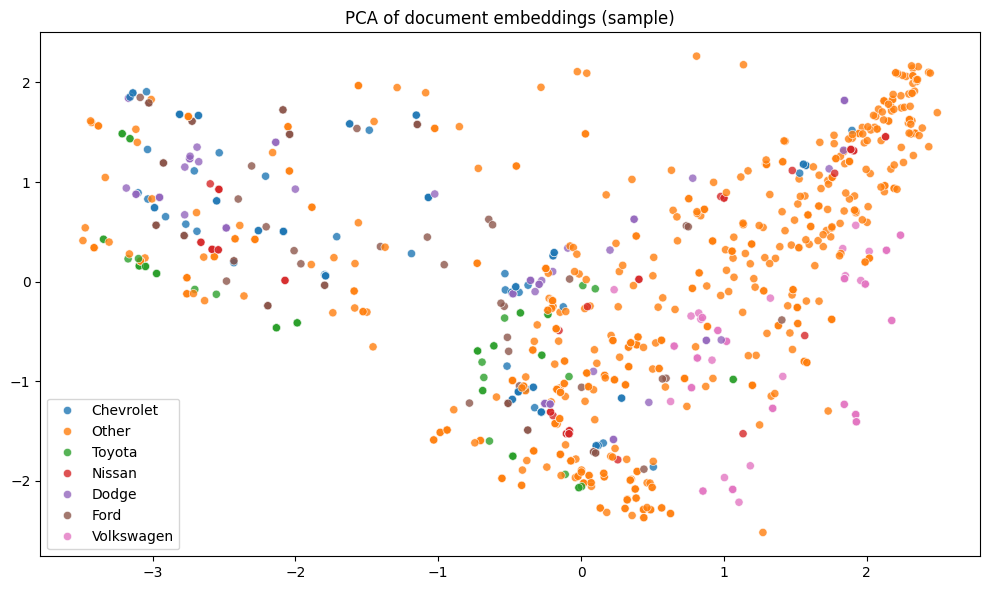

In [9]:
# sample to keep plotting fast
n = len(doc_embeddings)
sample_size = min(1000, n)
idx = np.random.choice(n, size=sample_size, replace=False)
X_sample = doc_embeddings[idx]
meta = df.iloc[idx].reset_index(drop=True)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_sample)

# pick top makes for coloring
top_makes = df['Make'].value_counts().nlargest(6).index.tolist()
meta['make_small'] = meta['Make'].apply(lambda x: x if x in top_makes else 'Other')

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=meta['make_small'], palette='tab10', s=35, alpha=0.8)
plt.title('PCA of document embeddings (sample)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Conclusion
- Bag-of-Words (counts) produces a sparse matrix of word frequencies.
- Normalized BoW (L1) scales counts by document length for uniformity.
- TF-IDF highlights informative words across the corpus.
- Word2Vec trained on the corpus yields dense word vectors capturing semantic similarity; averaging these gives simple document embeddings suitable for downstream tasks and visualization.

Files written: `document_embeddings.csv`, `word2vec.model`.

Next steps (optional): tuning Word2Vec hyperparameters, using Doc2Vec for direct document embeddings, or applying clustering/classification on the derived features.